# Step 2: Does the effect exist?

**Uses year 1 (TRAIN) only.** We never look at year 2 here, so it stays a fair test later.

Questions:
1. Do big closing imbalances push the closing price? *(mechanism, powers the cost alert)*
2. Do they reverse overnight? *(the strategy's profit)*
3. Is the profit real or a few lucky nights?
4. Is it bigger on forced-flow days (rebalances, quarter-end)?
5. Which clues might separate forced from informed imbalances? *(preview of the filter)*

Run `build_table.py` first so `data/features.parquet` exists.

**All bounce and push numbers are market-adjusted:** each stock's move minus the average move of all 100 stocks that night. Otherwise a market-wide rally would look like strategy profit.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Chart style: thin marks, quiet grid, one axis
BLUE, RED, GRAY, INK, INK2 = "#2a78d6", "#e34948", "#9a9993", "#0b0b0b", "#52514e"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#d6d5d0", "axes.grid": True, "grid.color": "#ebeae6",
    "grid.linewidth": 0.8, "axes.axisbelow": True, "axes.spines.top": False,
    "axes.spines.right": False, "axes.titleweight": "bold", "axes.titlesize": 12,
    "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2, "font.size": 10,
})
pd.set_option("display.width", 160)

df = pd.read_parquet("data/features.parquet")
if "bounce_raw_bps" not in df.columns:
    raise SystemExit("Old features file. Re-run:  python build_table.py")
tr = df[(~df["bad_row"]) & (df["split"] == "train")].copy()
print(f"TRAIN rows: {len(tr):,}  |  {tr['date'].min().date()} to {tr['date'].max().date()}")

TRAIN rows: 23,554  |  2024-10-15 to 2025-09-30


In [2]:
def day_tstat(trades, col="fade_bounce_bps"):
    """Average per DAY first (stocks on the same night move together), then t-stat."""
    daily = trades.groupby("date")[col].mean()
    if len(daily) < 3:
        return np.nan, np.nan, daily
    t = daily.mean() / (daily.std() / np.sqrt(len(daily)))
    sharpe = daily.mean() / daily.std() * np.sqrt(252)
    return t, sharpe, daily

def bar_by_group(series, title, ylabel, note):
    """Bars colored by sign: blue = up, red = down."""
    fig, ax = plt.subplots(figsize=(9, 4.2))
    colors = [BLUE if v >= 0 else RED for v in series.values]
    ax.bar(series.index.astype(str), series.values, color=colors, width=0.6)
    ax.axhline(0, color=INK2, lw=1)
    for x, v in zip(series.index.astype(str), series.values):
        ax.annotate(f"{v:+.1f}", (x, v), ha="center", va="bottom" if v >= 0 else "top",
                    fontsize=9, color=INK, xytext=(0, 3 if v >= 0 else -3), textcoords="offset points")
    ax.margins(y=0.18)
    ax.set_title(title, loc="left")
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Imbalance group  (1 = biggest SELL imbalance  ...  10 = biggest BUY imbalance)")
    fig.text(0.01, -0.03, note, fontsize=9, color=INK2)
    plt.tight_layout()
    plt.show()

## 1. The 10-group chart: overnight bounce

Every stock-day is sorted by `imb_pct_adv` (imbalance as % of normal daily volume) and split into 10 equal groups.

**If the idea works:** group 1 (big sell imbalances) shows a **positive** next-morning return, group 10 (big buy imbalances) a **negative** one, and the middle sits near zero.

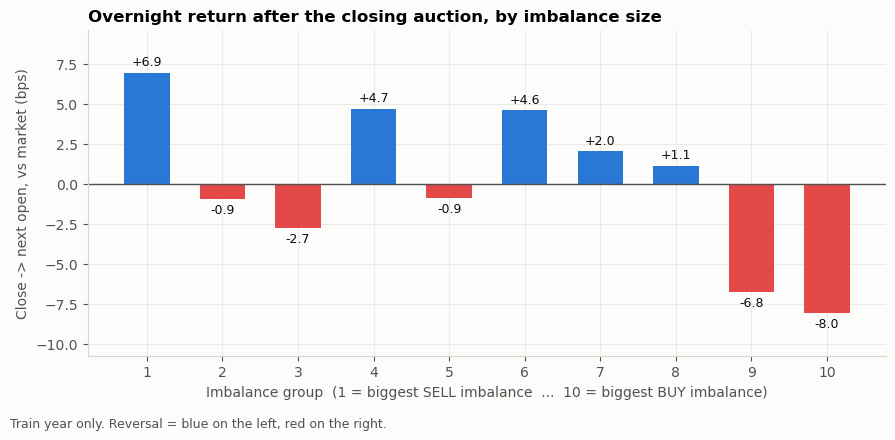

,imb_pct_adv_range,mean_bounce_bps,median_bounce_bps,n
group,,,,
1,-47.73 .. -3.17,6.9,-1.5,2356
2,-3.17 .. -1.74,-0.9,-5.4,2355
3,-1.74 .. -0.87,-2.7,-2.1,2355
4,-0.87 .. -0.27,4.7,-0.9,2356
5,-0.27 .. 0.10,-0.9,-4.3,2355
6,0.10 .. 0.61,4.6,-1.5,2355
7,0.61 .. 1.21,2.0,-3.6,2356
8,1.21 .. 2.04,1.1,-3.3,2355
9,2.04 .. 3.52,-6.8,-7.1,2355


In [3]:
tr["group"] = pd.qcut(tr["imb_pct_adv"], 10, labels=range(1, 11))
g = tr.groupby("group", observed=True)

bar_by_group(g["bounce_bps"].mean(),
             "Overnight return after the closing auction, by imbalance size",
             "Close -> next open, vs market (bps)",
             "Train year only. Reversal = blue on the left, red on the right.")

summary = pd.DataFrame({
    "imb_pct_adv_range": g["imb_pct_adv"].agg(lambda x: f"{x.min():.2f} .. {x.max():.2f}"),
    "mean_bounce_bps": g["bounce_bps"].mean().round(1),
    "median_bounce_bps": g["bounce_bps"].median().round(1),
    "n": g.size(),
})
summary

## 2. The mechanism: does the imbalance push the close?

Same groups, but now the move from **3:55 PM to the close**. Buy imbalances should push the close **up** (blue on the right). This is what the cost alert will predict.

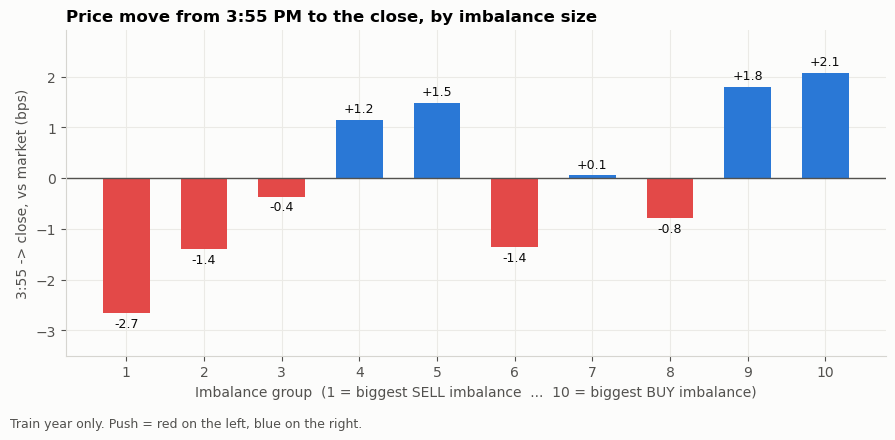

In [4]:
bar_by_group(g["push_bps"].mean(),
             "Price move from 3:55 PM to the close, by imbalance size",
             "3:55 -> close, vs market (bps)",
             "Train year only. Push = red on the left, blue on the right.")

## 3. Is the profit real? Fade the biggest imbalances

Strategy: each day, bet **against** the stocks whose imbalance is in the top X% by size. Profit per trade = `fade_bounce_bps`.

How to read the table:
- **t-stat > 2**: probably real. **< 1.5**: could be luck.
- **mean far above median**: a few big nights drive the result.
- **trimmed mean** removes the top and bottom 1% of trades. If it collapses, it was outliers.
- **raw_mean_bps** is before removing the market's move. If `mean_bps` is much smaller, the raw result was mostly market luck.
- **Sharpe before costs** is rough. Costs (~3 bps per trade) come out later in `backtest.py`.

In [5]:
abs_imb = tr["imb_pct_adv"].abs()
rows = []
for top in [0.30, 0.20, 0.10, 0.05, 0.02]:
    trades = tr[abs_imb >= abs_imb.quantile(1 - top)]
    t, sharpe, daily = day_tstat(trades)
    lo, hi = trades["fade_bounce_bps"].quantile([0.01, 0.99])
    rows.append({
        "top_%": int(top * 100),
        "trades": len(trades),
        "trades_per_day": round(len(trades) / tr["date"].nunique(), 1),
        "raw_mean_bps": trades["fade_bounce_raw_bps"].mean(),
        "mean_bps": trades["fade_bounce_bps"].mean(),
        "median_bps": trades["fade_bounce_bps"].median(),
        "trimmed_mean_bps": trades["fade_bounce_bps"].clip(lo, hi).mean(),
        "win_rate": trades["reversed"].mean(),
        "t_stat": t,
        "sharpe_before_costs": sharpe,
    })
pd.DataFrame(rows).round(2)

,top_%,trades,trades_per_day,raw_mean_bps,mean_bps,median_bps,trimmed_mean_bps,win_rate,t_stat,sharpe_before_costs
0,30,7066,29.8,5.51,6.12,3.74,5.75,0.53,2.47,2.55
1,20,4711,19.9,8.48,7.38,4.38,7.19,0.53,1.97,2.04
2,10,2356,9.9,6.94,4.46,3.07,4.56,0.52,0.61,0.63
3,5,1178,5.0,11.80,11.37,6.56,11.74,0.55,2.82,3.07
4,2,472,2.0,10.36,6.29,5.68,9.80,0.53,1.19,1.68


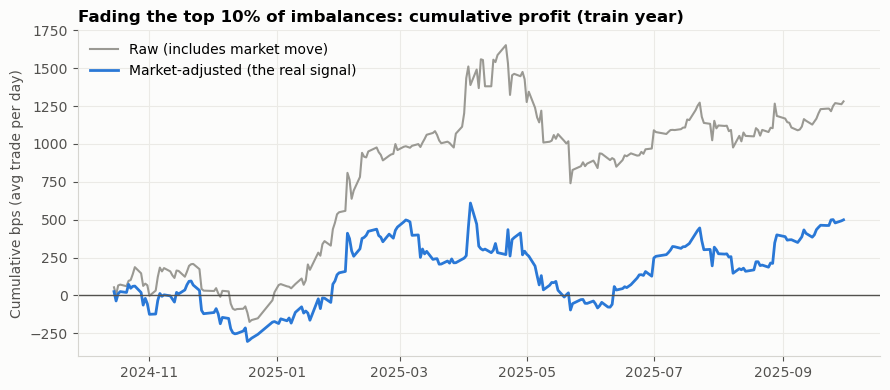

A steady blue climb = consistent edge. Big jumps = a handful of nights doing the work.


In [6]:
# Cumulative profit of fading the top 10%, averaged per day (train year, before costs)
trades = tr[abs_imb >= abs_imb.quantile(0.90)]
_, _, daily = day_tstat(trades)
_, _, daily_raw = day_tstat(trades, "fade_bounce_raw_bps")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(daily_raw.index, daily_raw.cumsum(), color=GRAY, lw=1.5, label="Raw (includes market move)")
ax.plot(daily.index, daily.cumsum(), color=BLUE, lw=2, label="Market-adjusted (the real signal)")
ax.axhline(0, color=INK2, lw=1)
ax.set_title("Fading the top 10% of imbalances: cumulative profit (train year)", loc="left")
ax.set_ylabel("Cumulative bps (avg trade per day)")
ax.legend(frameon=False, loc="upper left")
plt.tight_layout(); plt.show()
print("A steady blue climb = consistent edge. Big jumps = a handful of nights doing the work.")

### Robustness: is it one lucky stretch?

April 2025 had huge market-wide overnight swings (tariff shock). If the edge disappears without it, it was luck. We also split the year into quarters: a real effect should show up in most of them.

In [7]:
def stats(trades, label):
    t, sharpe, _ = day_tstat(trades)
    return {"sample": label, "trades": len(trades),
            "mean_bps": round(trades["fade_bounce_bps"].mean(), 1),
            "t_stat": round(t, 2), "sharpe_before_costs": round(sharpe, 2)}

top5 = tr[abs_imb >= abs_imb.quantile(0.95)]
top10 = tr[abs_imb >= abs_imb.quantile(0.90)]
no_april = lambda x: x[~((x["date"] >= "2025-04-01") & (x["date"] <= "2025-04-30"))]

rows = [stats(top10, "top 10%, all"), stats(no_april(top10), "top 10%, excluding Apr 2025"),
        stats(top5, "top 5%, all"), stats(no_april(top5), "top 5%, excluding Apr 2025")]
for q, part in top5.groupby(top5["date"].dt.to_period("Q")):
    rows.append(stats(part, f"top 5%, {q}"))
pd.DataFrame(rows)

,sample,trades,mean_bps,t_stat,sharpe_before_costs
0,"top 10%, all",2356,4.5,0.61,0.63
1,"top 10%, excluding Apr 2025",2170,2.6,0.65,0.71
2,"top 5%, all",1178,11.4,2.82,3.07
3,"top 5%, excluding Apr 2025",1087,8.6,2.87,3.26
4,"top 5%, 2024Q4",333,-3.7,0.42,0.97
5,"top 5%, 2025Q1",258,15.6,1.56,3.38
6,"top 5%, 2025Q2",338,20.5,1.56,3.38
7,"top 5%, 2025Q3",249,14.8,1.87,3.93


## 4. Forced-flow days vs normal days

On rebalance and quarter-end days, index funds *must* trade at the close. If our story is right, those imbalances should reverse **more**.

In [8]:
flags = ["is_special_day", "is_quarter_end", "is_month_end", "is_triple_witching", "is_opex"]
rows = []
for f in flags:
    for val in [True, False]:
        s = trades[trades[f] == val]
        if len(s):
            rows.append({"flag": f, "value": val, "trades": len(s),
                         "mean_fade_bps": round(s["fade_bounce_bps"].mean(), 1),
                         "win_rate": round(s["reversed"].mean(), 2)})
pd.DataFrame(rows)

,flag,value,trades,mean_fade_bps,win_rate
0,is_special_day,True,522,7.9,0.54
1,is_special_day,False,1834,3.5,0.52
2,is_quarter_end,True,70,-3.9,0.51
3,is_quarter_end,False,2286,4.7,0.52
4,is_month_end,True,273,3.0,0.53
5,is_month_end,False,2083,4.7,0.52
6,is_triple_witching,True,220,11.7,0.57
7,is_triple_witching,False,2136,3.7,0.52
8,is_opex,True,300,4.0,0.56
9,is_opex,False,2056,4.5,0.52


## 5. Preview of the filter: which clues point to informed flow?

Among the top-10% trades, split by each clue. A clue is useful if the two halves give **clearly different** profits.

- `move_with_imb > 0`: the stock already moved the same way as the imbalance today (chasing news?)
- `prev_volume_ratio` high: unusual activity yesterday (earnings week?)
- `imb_growth_pct_adv` high: the imbalance kept growing from 3:50 to 3:55 (big index orders arriving?)
- `imb_flipped`: the imbalance changed direction since 3:50

In [9]:
def split_by(trades, col, label_hi, label_lo, thresh=None):
    thresh = trades[col].median() if thresh is None else thresh
    hi, lo = trades[trades[col] > thresh], trades[trades[col] <= thresh]
    return [
        {"clue": col, "group": label_hi, "trades": len(hi),
         "mean_fade_bps": hi["fade_bounce_bps"].mean(), "win_rate": hi["reversed"].mean()},
        {"clue": col, "group": label_lo, "trades": len(lo),
         "mean_fade_bps": lo["fade_bounce_bps"].mean(), "win_rate": lo["reversed"].mean()},
    ]

rows = []
rows += split_by(trades, "move_with_imb", "moved WITH imbalance", "moved AGAINST / flat", thresh=0)
rows += split_by(trades, "prev_volume_ratio", "high volume yesterday", "normal volume yesterday")
rows += split_by(trades, "imb_growth_pct_adv", "imbalance grew a lot", "grew little")
rows += split_by(trades.assign(f=trades["imb_flipped"].astype(int)), "f", "flipped direction", "same direction", thresh=0)
pd.DataFrame(rows).round(2)

,clue,group,trades,mean_fade_bps,win_rate
0,move_with_imb,moved WITH imbalance,1487,6.15,0.54
1,move_with_imb,moved AGAINST / flat,869,1.57,0.49
2,prev_volume_ratio,high volume yesterday,1178,4.54,0.52
3,prev_volume_ratio,normal volume yesterday,1178,4.38,0.52
4,imb_growth_pct_adv,imbalance grew a lot,1178,8.06,0.53
5,imb_growth_pct_adv,grew little,1178,0.86,0.52
6,f,flipped direction,280,-6.18,0.49
7,f,same direction,2076,5.90,0.53


## What to do with these results

| What you see | Next move |
|---|---|
| Section 1 slopes down, t-stat > 2 | The core strategy works. Build `backtest.py` next |
| Effect only in the top 2–5% | Trade fewer, bigger imbalances. That's fine |
| Much stronger on special days (section 4) | Make forced-flow days the center of the story |
| A clue splits profits clearly (section 5) | That clue goes into the reversal model / filter |
| Section 2 is strong but section 1 is flat | The push is real but doesn't reverse: lead with the **cost alert** |

Write down every threshold you pick here. Those choices get frozen before touching year 2.

In [10]:
top5 = tr[abs_imb >= abs_imb.quantile(0.95)].copy()
top5["side_name"] = np.where(top5["imb"] > 0, "BUY imbalance", "SELL imbalance")
rows = []
for name, part in top5.groupby("side_name"):
    rows.append(stats(part, f"top 5%, {name}"))
    good = part[(~part["imb_flipped"]) & (part["imb_growth_pct_adv"] > 0)]
    rows.append(stats(good, f"top 5%, {name}, not flipped & grew"))
pd.DataFrame(rows)

,sample,trades,mean_bps,t_stat,sharpe_before_costs
0,"top 5%, BUY imbalance",620,10.5,1.14,1.42
1,"top 5%, BUY imbalance, not flipped & grew",406,8.5,0.93,1.25
2,"top 5%, SELL imbalance",558,12.3,1.94,2.44
3,"top 5%, SELL imbalance, not flipped & grew",362,18.2,2.27,3.08


In [11]:
print(abs_imb.quantile(0.95))

6.693295331650862
